In [1]:
# import the packages 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# reading the data
data = pd.read_csv("data/stud.csv")

In [3]:
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
# duplicate check 
data.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
# duplicate check 
data.duplicated().sum()

np.int64(0)

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
# Statistics
data.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
data.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [11]:
# Categorical Feature Intrepting
print("The Unique values for gender feature is:",end = " ")
print(data['gender'].unique())
print("The Unique values for race_ethnicity feature is:",end = " ")
print(data['race_ethnicity'].unique())
print("The Unique values for parental_level_of_education feature is:",end = " ")
print(data['parental_level_of_education'].unique())
print("The Unique values for lunch feature is:",end = " ")
print(data['lunch'].unique())
print("The Unique values for test_preparation_course feature is:",end = " ")
print(data['test_preparation_course'].unique())

The Unique values for gender feature is: <StringArray>
['female', 'male']
Length: 2, dtype: str
The Unique values for race_ethnicity feature is: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
The Unique values for parental_level_of_education feature is: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
The Unique values for lunch feature is: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
The Unique values for test_preparation_course feature is: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [12]:
# numerical and Categorical features
numerical_features = data.select_dtypes(exclude="object").columns
catgorical_features = data.select_dtypes(include="object").columns


print(f"There are {len(numerical_features)} featues:{numerical_features}")
print(f"There are {len(catgorical_features)} features:{catgorical_features}")

There are 3 featues:Index(['math_score', 'reading_score', 'writing_score'], dtype='str')
There are 5 features:Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')


In [13]:
# Creating "Total_Score" and "Average column"
data['Total_score'] = data['math_score']+data['reading_score']+data['writing_score']
data['average'] = data['Total_score']/3

In [14]:
data.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


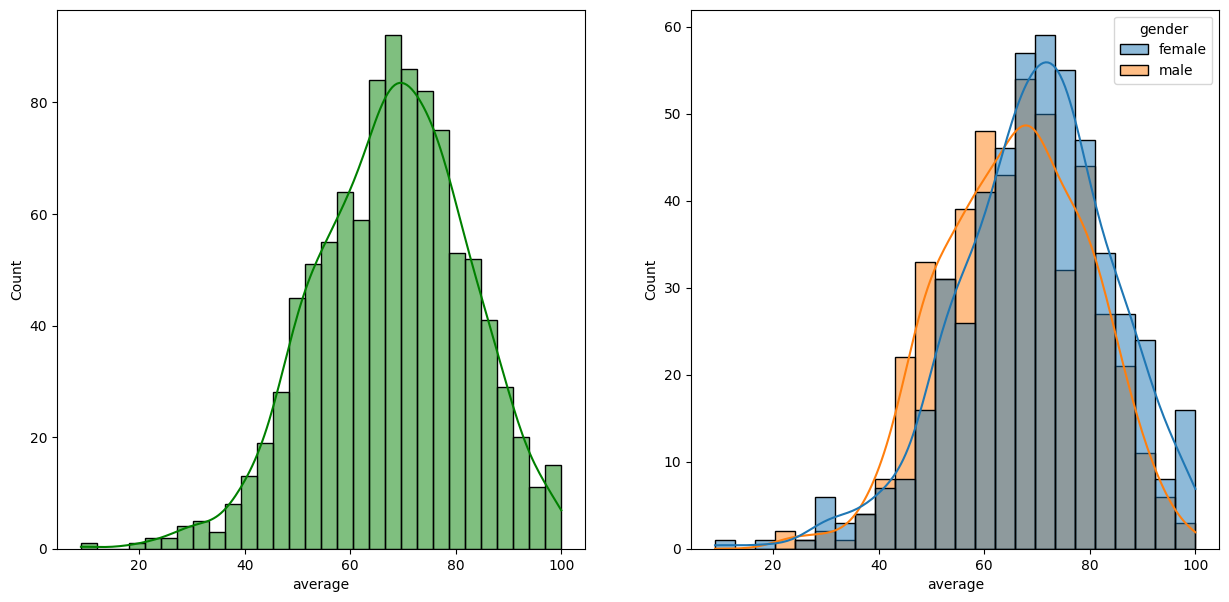

In [15]:
# Visualizations
fig,axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data = data,x='average',bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data = data,x='average',kde=True,hue='gender')
plt.show()

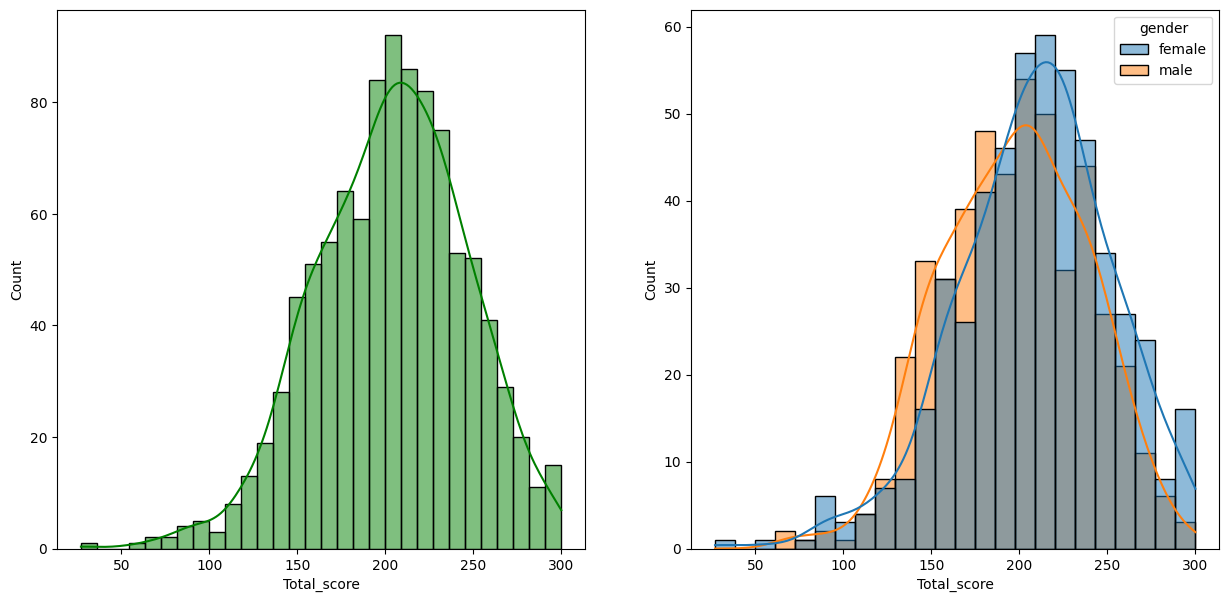

In [16]:
fig,axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data = data,x='Total_score',bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data = data,x='Total_score',kde=True,hue='gender')
plt.show()

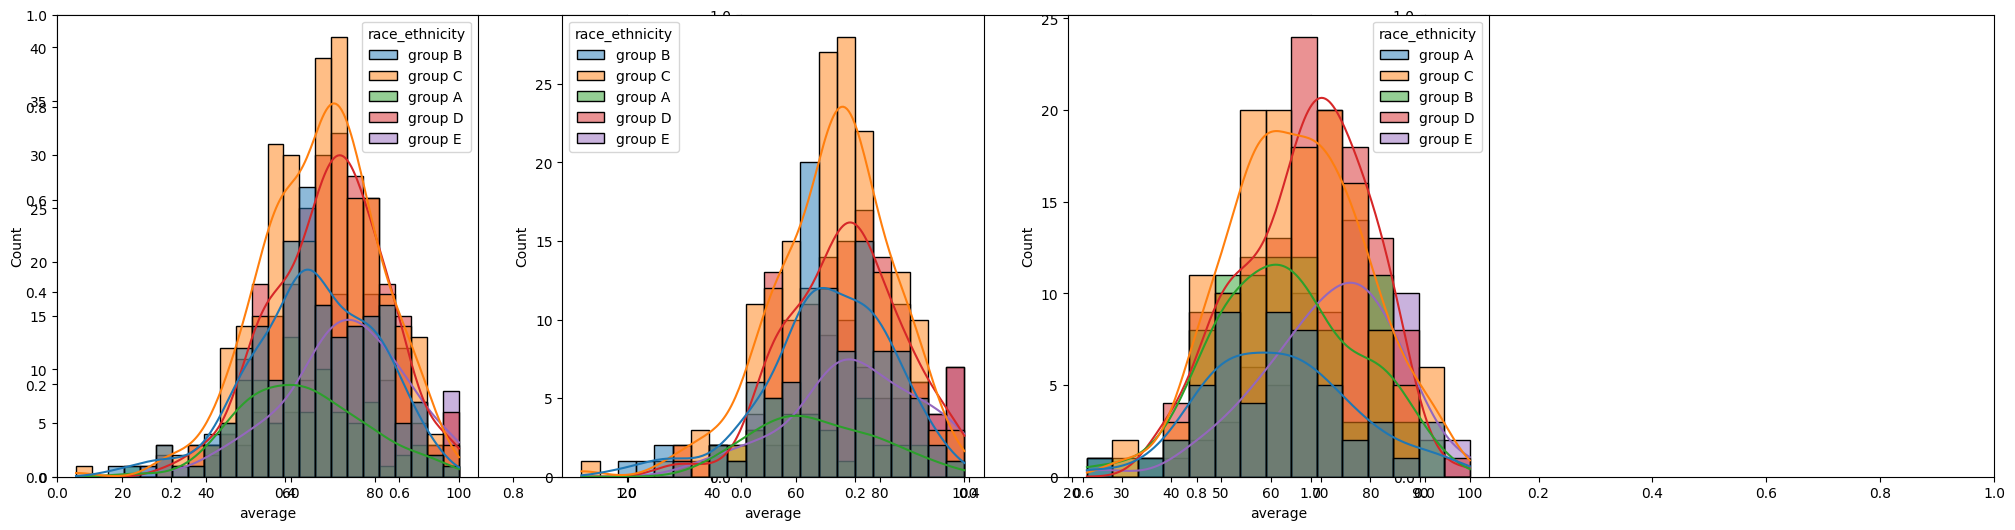

In [18]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=data,x='average',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax =sns.histplot(data=data[data.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax =sns.histplot(data=data[data.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

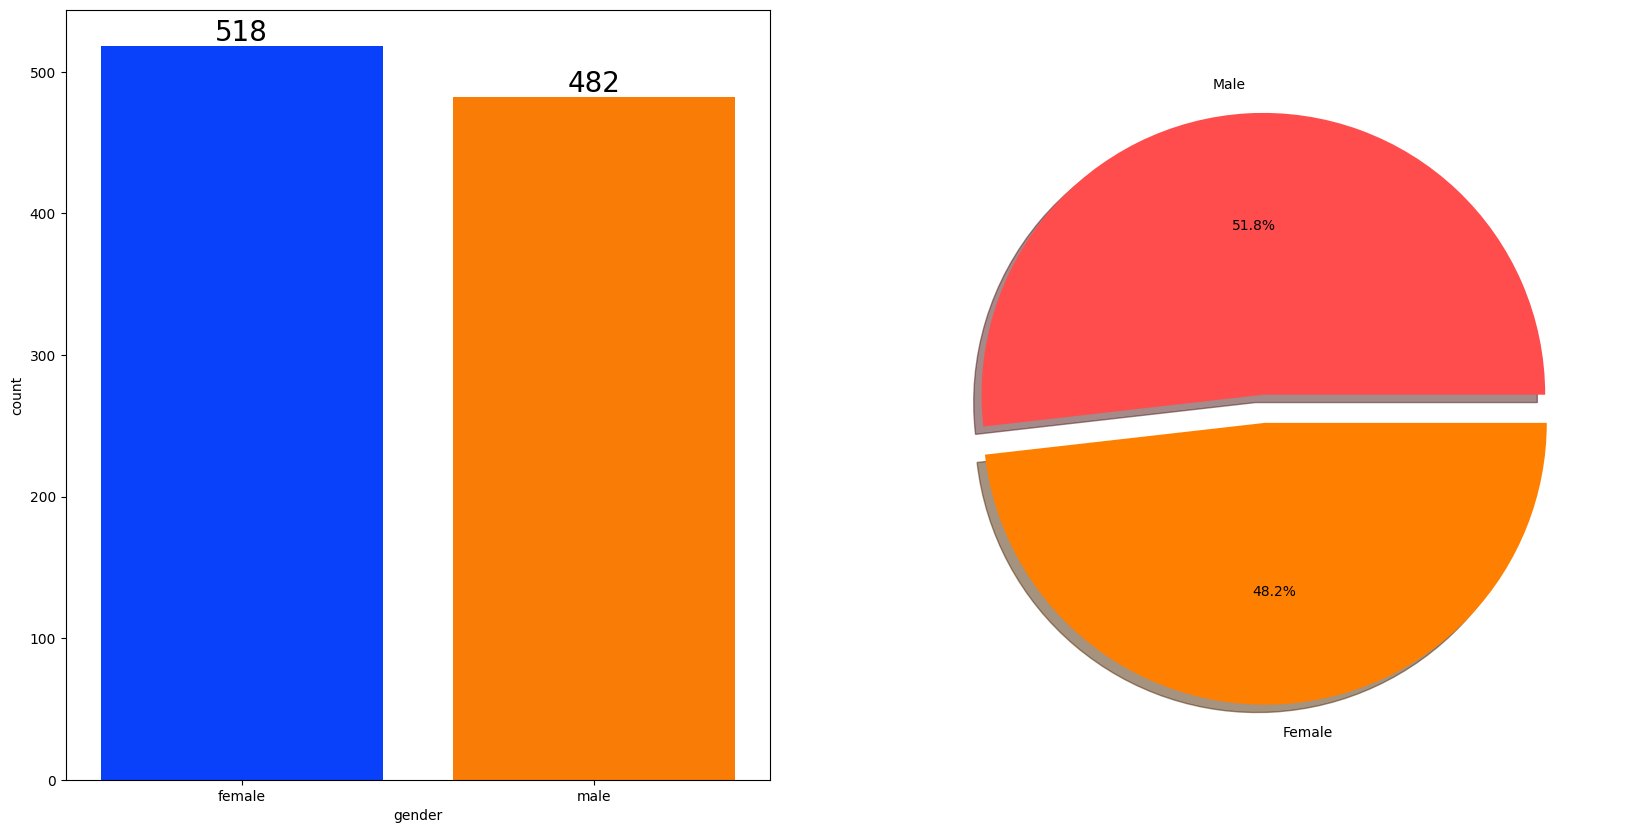

In [19]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=data['gender'],data=data,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=data['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()